In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Make project-level src modules importable when the notebook is run from notebooks/.
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.analysis import prepare_day_analysis, prepare_hour_analysis
from src.statistics import benjamini_hochberg

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/marketing_AB_clean.csv")

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")


Rows: 588,101
Columns: 6


In [2]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

df["most ads day"] = pd.Categorical(
    df["most ads day"],
    categories=day_order,
    ordered=True
)

print(df["most ads day"].cat.categories.tolist())

['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']


In [3]:
day_summary = (
    df.groupby(["most ads day", "test group"], observed=True)["converted"]
    .agg(
        users="count",
        conversions="sum"
    )
    .reset_index()
)

day_summary["conversion_rate"] = (
    day_summary["conversions"] / day_summary["users"]
)

day_summary["conversion_rate_pct"] = (
    day_summary["conversion_rate"] * 100
)

day_summary

,most ads day,test group,users,conversions,conversion_rate,conversion_rate_pct
0,Monday,ad,83571,2778,0.033241,3.324120
1,Monday,psa,3502,79,0.022559,2.255854
2,Tuesday,ad,74572,2270,0.030440,3.044038
3,Tuesday,psa,2907,42,0.014448,1.444788
4,Wednesday,ad,77418,1963,0.025356,2.535586
5,Wednesday,psa,3490,55,0.015759,1.575931
6,Thursday,ad,79077,1711,0.021637,2.163714
7,Thursday,psa,3905,79,0.020230,2.023047
8,Friday,ad,88805,1995,0.022465,2.246495
9,Friday,psa,3803,62,0.016303,1.630292


In [4]:
day_results = prepare_day_analysis(df)

# Rename reusable-function output columns to the notebook's established schema.
day_results = day_results.rename(columns={
    "treatment_users": "ad_users",
    "control_users": "psa_users",
    "treatment_conversions": "ad_conversions",
    "control_conversions": "psa_conversions",
    "treatment_rate": "ad_conversion_rate",
    "control_rate": "psa_conversion_rate",
    "adjusted_p_value": "p_value_adjusted"
})

day_results


,most ads day,ad_users,psa_users,ad_conversions,psa_conversions,ad_conversion_rate,psa_conversion_rate,absolute_difference,relative_lift,z_statistic,p_value,ci_lower,ci_upper,cohens_h,p_value_adjusted,significant_after_bh
0,Monday,83571,3502,2778,79,0.033241,0.022559,0.010683,0.473553,3.476598,5.078178e-04,0.005617,0.015749,0.065163,0.001185,True
1,Tuesday,74572,2907,2270,42,0.030440,0.014448,0.015992,1.106909,4.971771,6.634401e-07,0.011483,0.020502,0.109757,0.000005,True
2,Wednesday,77418,3490,1963,55,0.025356,0.015759,0.009597,0.608945,3.556091,3.764133e-04,0.005319,0.013874,0.068096,0.001185,True
3,Thursday,79077,3905,1711,79,0.021637,0.020230,0.001407,0.069532,0.590657,5.547506e-01,-0.003124,0.005937,0.009827,0.554751,False
4,Friday,88805,3803,1995,62,0.022465,0.016303,0.006162,0.377971,2.525029,1.156888e-02,0.002021,0.010303,0.044835,0.016196,True
5,Saturday,78802,2858,1679,40,0.021307,0.013996,0.007311,0.522354,2.674512,7.483818e-03,0.002887,0.011734,0.055819,0.013097,True
6,Sunday,82332,3059,2027,63,0.024620,0.020595,0.004025,0.195430,1.414599,1.571861e-01,-0.001118,0.009168,0.027103,0.183384,False


In [5]:
# Benjamini–Hochberg correction is already applied by prepare_day_analysis.
day_results[[
    "most ads day",
    "absolute_difference",
    "p_value",
    "p_value_adjusted",
    "significant_after_bh"
]]


,most ads day,absolute_difference,p_value,p_value_adjusted,significant_after_bh
0,Monday,0.010683,5.078178e-04,0.001185,True
1,Tuesday,0.015992,6.634401e-07,0.000005,True
2,Wednesday,0.009597,3.764133e-04,0.001185,True
3,Thursday,0.001407,5.547506e-01,0.554751,False
4,Friday,0.006162,1.156888e-02,0.016196,True
5,Saturday,0.007311,7.483818e-03,0.013097,True
6,Sunday,0.004025,1.571861e-01,0.183384,False


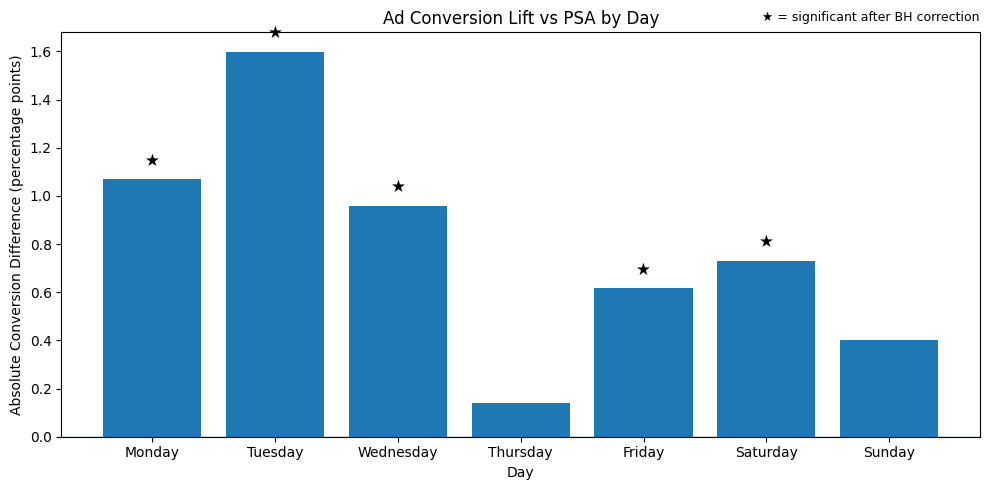

In [6]:
# Exploratory day-level lift chart. BH-significant bars are marked with ★.
day_chart = day_results.copy()
day_chart["absolute_difference_pp"] = day_chart["absolute_difference"] * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(day_chart["most ads day"].astype(str), day_chart["absolute_difference_pp"])
ax.axhline(0, linewidth=1)
ax.set_title("Ad Conversion Lift vs PSA by Day")
ax.set_xlabel("Day")
ax.set_ylabel("Absolute Conversion Difference (percentage points)")

for bar, significant in zip(bars, day_chart["significant_after_bh"]):
    if significant:
        y = bar.get_height()
        offset = 0.04 if y >= 0 else -0.04
        va = "bottom" if y >= 0 else "top"
        ax.text(bar.get_x() + bar.get_width() / 2, y + offset, "★", ha="center", va=va, fontsize=12)

ax.text(1.0, 1.02, "★ = significant after BH correction", transform=ax.transAxes, ha="right", va="bottom", fontsize=9)
fig.tight_layout()
plt.show()


In [7]:
# The chart above is displayed in percentage points to make practical differences easier to read.
print("Day-level chart marker: ★ indicates significance after Benjamini–Hochberg correction.")


Day-level chart marker: ★ indicates significance after Benjamini–Hochberg correction.


In [8]:
hour_summary = (
    df.groupby(["most ads hour", "test group"], observed=True)["converted"]
    .agg(
        users="count",
        conversions="sum"
    )
    .reset_index()
)

hour_summary["conversion_rate"] = (
    hour_summary["conversions"]
    / hour_summary["users"]
)

hour_summary["conversion_rate_pct"] = (
    hour_summary["conversion_rate"] * 100
)

hour_summary.head(10)

,most ads hour,test group,users,conversions,conversion_rate,conversion_rate_pct
0,0,ad,5309,102,0.019213,1.921266
1,0,psa,227,0,0.000000,0.000000
2,1,ad,4615,62,0.013434,1.343445
3,1,psa,187,0,0.000000,0.000000
4,2,ad,5152,39,0.007570,0.756988
5,2,psa,181,0,0.000000,0.000000
6,3,ad,2590,27,0.010425,1.042471
7,3,psa,89,1,0.011236,1.123596
8,4,ad,694,11,0.015850,1.585014
9,4,psa,28,0,0.000000,0.000000


In [9]:
hour_results = prepare_hour_analysis(df)

hour_results = hour_results.rename(columns={
    "treatment_users": "ad_users",
    "control_users": "psa_users",
    "treatment_conversions": "ad_conversions",
    "control_conversions": "psa_conversions",
    "treatment_rate": "ad_conversion_rate",
    "control_rate": "psa_conversion_rate",
    "adjusted_p_value": "p_value_adjusted"
})

hour_results


,most ads hour,ad_users,psa_users,ad_conversions,psa_conversions,ad_conversion_rate,psa_conversion_rate,absolute_difference,relative_lift,z_statistic,p_value,ci_lower,ci_upper,cohens_h,p_value_adjusted,significant_after_bh
0,0,5309,227,102,0,0.019213,0.000000,0.019213,NaN,2.107875,0.035042,0.015520,0.022905,0.278115,0.112413,False
1,1,4615,187,62,0,0.013434,0.000000,0.013434,NaN,1.595338,0.110637,0.010113,0.016756,0.232336,0.204252,False
2,2,5152,181,39,0,0.007570,0.000000,0.007570,NaN,1.174837,0.240060,0.005203,0.009937,0.174230,0.340253,False
3,3,2590,89,27,1,0.010425,0.011236,-0.000811,-0.072201,-0.073994,0.941015,-0.023056,0.021434,-0.007839,0.941015,False
4,4,694,28,11,0,0.015850,0.000000,0.015850,NaN,0.671320,0.502017,0.006558,0.025142,0.252465,0.593839,False
5,5,742,23,16,0,0.021563,0.000000,0.021563,NaN,0.711724,0.476636,0.011112,0.032015,0.294755,0.593839,False
6,6,1985,83,46,0,0.023174,0.000000,0.023174,NaN,1.402563,0.160747,0.016555,0.029793,0.305647,0.275567,False
7,7,6168,237,114,2,0.018482,0.008439,0.010044,1.190175,1.137833,0.255190,-0.002078,0.022165,0.088760,0.340253,False
8,8,16968,659,337,7,0.019861,0.010622,0.009239,0.869763,1.682179,0.092534,0.001135,0.017343,0.076305,0.196454,False
9,9,29802,1202,582,13,0.019529,0.010815,0.008714,0.805671,2.158843,0.030862,0.002659,0.014768,0.072039,0.112413,False


In [10]:
# Benjamini–Hochberg correction is already applied by prepare_hour_analysis.
hour_results[[
    "most ads hour",
    "ad_users",
    "psa_users",
    "absolute_difference",
    "p_value",
    "p_value_adjusted",
    "significant_after_bh"
]]


,most ads hour,ad_users,psa_users,absolute_difference,p_value,p_value_adjusted,significant_after_bh
0,0,5309,227,0.019213,0.035042,0.112413,False
1,1,4615,187,0.013434,0.110637,0.204252,False
2,2,5152,181,0.007570,0.240060,0.340253,False
3,3,2590,89,-0.000811,0.941015,0.941015,False
4,4,694,28,0.015850,0.502017,0.593839,False
5,5,742,23,0.021563,0.476636,0.593839,False
6,6,1985,83,0.023174,0.160747,0.275567,False
7,7,6168,237,0.010044,0.255190,0.340253,False
8,8,16968,659,0.009239,0.092534,0.196454,False
9,9,29802,1202,0.008714,0.030862,0.112413,False


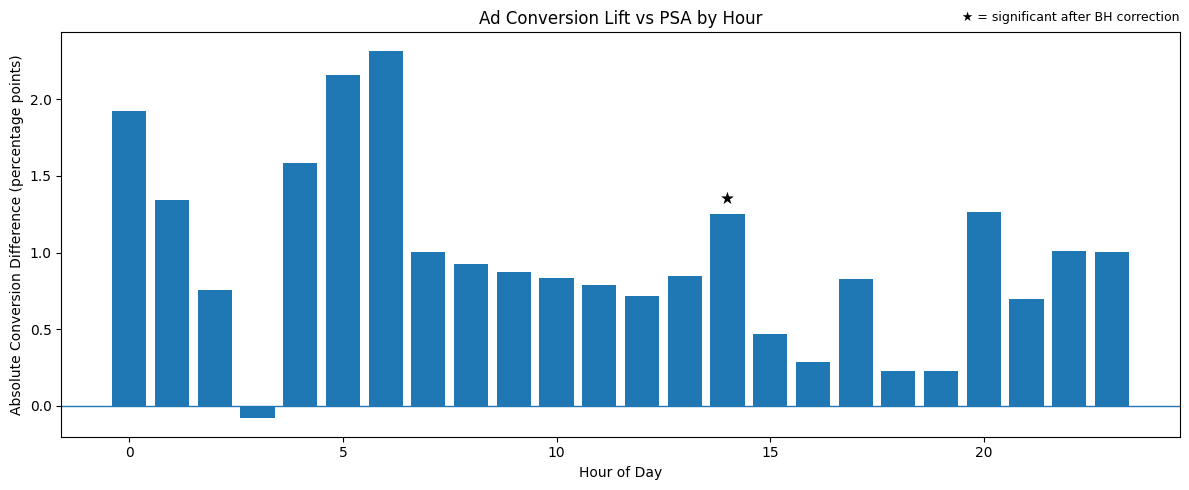

In [11]:
# Exploratory hourly lift chart. BH-significant bars are marked with ★.
hour_chart = hour_results.copy()
hour_chart["absolute_difference_pp"] = hour_chart["absolute_difference"] * 100

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(hour_chart["most ads hour"], hour_chart["absolute_difference_pp"])
ax.axhline(0, linewidth=1)
ax.set_title("Ad Conversion Lift vs PSA by Hour")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Absolute Conversion Difference (percentage points)")

for bar, significant in zip(bars, hour_chart["significant_after_bh"]):
    if significant:
        y = bar.get_height()
        offset = 0.04 if y >= 0 else -0.04
        va = "bottom" if y >= 0 else "top"
        ax.text(bar.get_x() + bar.get_width() / 2, y + offset, "★", ha="center", va=va, fontsize=12)

ax.text(1.0, 1.02, "★ = significant after BH correction", transform=ax.transAxes, ha="right", va="bottom", fontsize=9)
fig.tight_layout()
plt.show()


In [12]:
hour_evidence = hour_results.copy()

hour_evidence["absolute_difference_pp"] = hour_evidence["absolute_difference"] * 100
hour_evidence["ci_lower_pp"] = hour_evidence["ci_lower"] * 100
hour_evidence["ci_upper_pp"] = hour_evidence["ci_upper"] * 100
hour_evidence["relative_lift_pct"] = hour_evidence["relative_lift"] * 100

hour_evidence[[
    "most ads hour",
    "ad_users",
    "psa_users",
    "ad_conversion_rate",
    "psa_conversion_rate",
    "absolute_difference_pp",
    "ci_lower_pp",
    "ci_upper_pp",
    "p_value_adjusted",
    "significant_after_bh",
    "cohens_h"
]]


,most ads hour,ad_users,psa_users,ad_conversion_rate,psa_conversion_rate,absolute_difference_pp,ci_lower_pp,ci_upper_pp,p_value_adjusted,significant_after_bh,cohens_h
0,0,5309,227,0.019213,0.000000,1.921266,1.552007,2.290525,0.112413,False,0.278115
1,1,4615,187,0.013434,0.000000,1.343445,1.011288,1.675602,0.204252,False,0.232336
2,2,5152,181,0.007570,0.000000,0.756988,0.520307,0.993668,0.340253,False,0.174230
3,3,2590,89,0.010425,0.011236,-0.081124,-2.305627,2.143378,0.941015,False,-0.007839
4,4,694,28,0.015850,0.000000,1.585014,0.655784,2.514245,0.593839,False,0.252465
5,5,742,23,0.021563,0.000000,2.156334,1.111184,3.201484,0.593839,False,0.294755
6,6,1985,83,0.023174,0.000000,2.317380,1.655494,2.979266,0.275567,False,0.305647
7,7,6168,237,0.018482,0.008439,1.004367,-0.207786,2.216520,0.340253,False,0.088760
8,8,16968,659,0.019861,0.010622,0.923876,0.113501,1.734251,0.196454,False,0.076305
9,9,29802,1202,0.019529,0.010815,0.871358,0.265882,1.476835,0.112413,False,0.072039


In [13]:
significant_hours = hour_results[
    hour_results["significant_after_bh"]
].copy()

significant_hours["absolute_difference_pp"] = significant_hours["absolute_difference"] * 100
significant_hours["ci_lower_pp"] = significant_hours["ci_lower"] * 100
significant_hours["ci_upper_pp"] = significant_hours["ci_upper"] * 100

significant_hours[[
    "most ads hour",
    "ad_users",
    "psa_users",
    "absolute_difference_pp",
    "ci_lower_pp",
    "ci_upper_pp",
    "p_value_adjusted",
    "cohens_h"
]]


,most ads hour,ad_users,psa_users,absolute_difference_pp,ci_lower_pp,ci_upper_pp,p_value_adjusted,cohens_h
14,14,43779,1869,1.252398,0.661647,1.843149,0.03179,0.085645


## Segment Analysis Conclusion

### Day-of-Week Findings

The Ad treatment showed a positive conversion-rate difference relative to PSA across all seven days.

After Benjamini–Hochberg correction for multiple comparisons, statistically significant positive differences remained on:

- Monday: +1.07 percentage points
- Tuesday: +1.60 percentage points
- Wednesday: +0.96 percentage points
- Friday: +0.62 percentage points
- Saturday: +0.73 percentage points

Thursday (+0.14 pp) and Sunday (+0.40 pp) did not remain statistically significant after correction.

Although Tuesday showed the largest observed lift, segment-level results should not be interpreted as proof that the treatment is causally stronger on Tuesday. Day-of-week is an exploratory behavioral segmentation variable in this dataset.

### Hour-of-Day Findings

Twenty-four hourly treatment comparisons were evaluated and Benjamini–Hochberg correction was applied.

Only 14:00 remained statistically significant after correction:

- Ad − PSA difference: +1.25 percentage points
- 95% CI: +0.66 to +1.84 percentage points
- BH-adjusted p-value: 0.03179
- Cohen's h: 0.0856 (small effect)

Other hourly differences did not provide sufficient evidence after correction.

Several early-hour segments had very small PSA sample sizes and zero conversions. Their apparent relative lifts are therefore unstable and should not be used for targeting decisions.

### Overall Segment Interpretation

The overall experiment shows a clear positive conversion difference for the Ad group, while segment analysis indicates that the magnitude of the observed difference varies across days and hours.

However, most segment-specific effects are small, and only a limited number remain statistically significant after controlling the false discovery rate.

Therefore, segment analysis should be treated as exploratory evidence rather than as a basis for narrowly targeting specific days or hours.

The primary business decision should rely on the overall experiment result, experiment-validity checks, effect size, confidence interval, and business economics.

### Methodological caveat

Hourly z-test results for very low-volume segments should be interpreted cautiously because normal-approximation assumptions may be weak. These low-volume segments were not used for the business decision; hourly findings are exploratory and should not be ranked solely by relative lift.